<a href="https://colab.research.google.com/github/oerv13-gh/Ibero/blob/main/Redes_Neu_Sem5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
# 1. Descargar dataset desde Kaggle

path = kagglehub.dataset_download("fedesoriano/the-boston-houseprice-data")
print("Ruta descargada:", path)

root = Path(path)

# Buscar CSV
csv_files = list(root.rglob("*.csv"))
print("Archivos CSV encontrados:", csv_files)

df = pd.read_csv(csv_files[0])
print("\nColumnas:")
print(df.columns.tolist())

print("\nPrimeras 5 filas:")
print(df.head())


Using Colab cache for faster access to the 'the-boston-houseprice-data' dataset.
Ruta descargada: /kaggle/input/the-boston-houseprice-data
Archivos CSV encontrados: [PosixPath('/kaggle/input/the-boston-houseprice-data/boston.csv')]

Columnas:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

Primeras 5 filas:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.

In [3]:
# 2 definir x e y

target_col = "MEDV"
X = df.drop(columns=[target_col])
y = df[target_col]
print(f"\nNúmero de registros: {len(df)}")
print(f"Número de variables de entrada: {X.shape[1]}")
print(f"Variable objetivo: {target_col}")


Número de registros: 506
Número de variables de entrada: 13
Variable objetivo: MEDV


In [4]:
# 3. División entrenamiento / prueba

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
# 4. Escalado

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
# 5. Modelo DNN para regresión

model_reg = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)  # salida numérica
])


In [7]:
model_reg.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', 'mse']
)
model_reg.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 6. Early stopping

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [9]:
# 7. Entrenamiento

history_reg = model_reg.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 570.2596 - mae: 21.8635 - mse: 570.2596 - val_loss: 476.6383 - val_mae: 20.1538 - val_mse: 476.6383
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 465.2344 - mae: 19.2415 - mse: 465.2344 - val_loss: 334.0673 - val_mae: 16.2744 - val_mse: 334.0673
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 269.3344 - mae: 13.7105 - mse: 269.3344 - val_loss: 130.0735 - val_mae: 8.9534 - val_mse: 130.0735
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 107.3783 - mae: 7.9868 - mse: 107.3783 - val_loss: 50.7720 - val_mae: 5.0097 - val_mse: 50.7720
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 63.2515 - mae: 6.1430 - mse: 63.2515 - val_loss: 35.2404 - val_mae: 3.9654 - val_mse: 35.2404
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 40.8124 - mae: 4.7551 - mse: 40.8124 - val_loss: 29.9679 - val_mae: 3.7406 - val_mse: 29.9679
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 35

In [10]:
# 8. Evaluación

y_pred = model_reg.predict(X_test_scaled, verbose=0).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nResultados del modelo de regresión")
print("-" * 40)
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")


Resultados del modelo de regresión
----------------------------------------
MAE : 2.4349
MSE : 12.6544
RMSE: 3.5573
R²  : 0.8274


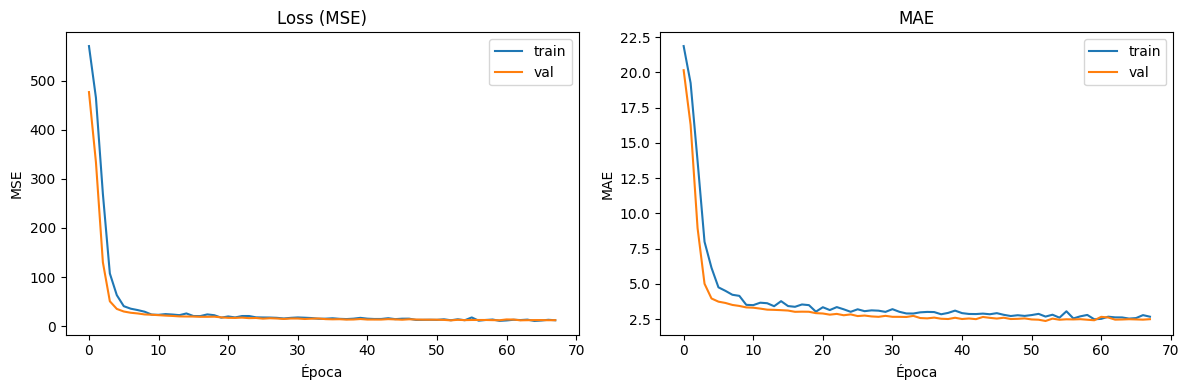

In [11]:
# 9. Gráficas de entrenamiento

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_reg.history['loss'], label='train')
plt.plot(history_reg.history['val_loss'], label='val')
plt.title("Loss (MSE)")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_reg.history['mae'], label='train')
plt.plot(history_reg.history['val_mae'], label='val')
plt.title("MAE")
plt.xlabel("Época")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
# 10. Tabla de ejemplo

n_inicio = 50 ;
n_fin = 60 ;

resultados_reg = pd.DataFrame({
    "Real": y_test.values[n_inicio:n_fin],
    "Predicho": y_pred[n_inicio:n_fin],
    "Error": y_test.values[n_inicio:n_fin] - y_pred[n_inicio:n_fin]
})
print("\nPrimeras predicciones:")
print(resultados_reg)


Primeras predicciones:
   Real   Predicho     Error
0  18.9  16.912352  1.987648
1  35.4  33.860859  1.539141
2  15.2  16.725090 -1.525090
3  26.5  24.096531  2.403469
4  43.5  41.076492  2.423508
5  21.2  22.534636 -1.334636
6  18.4  17.544439  0.855561
7  28.5  32.881752 -4.381752
8  23.9  24.683804 -0.783804
9  18.5  15.442475  3.057525


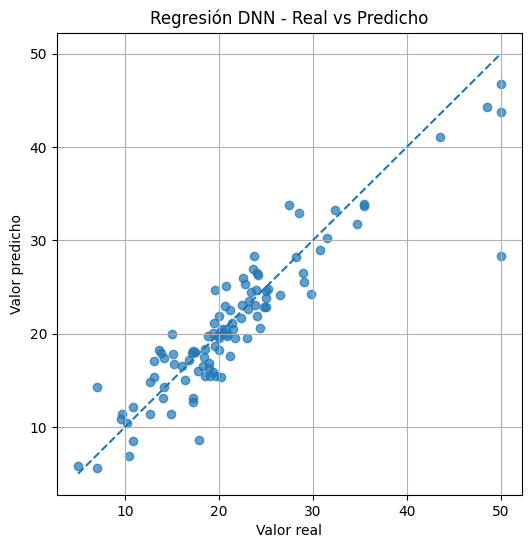

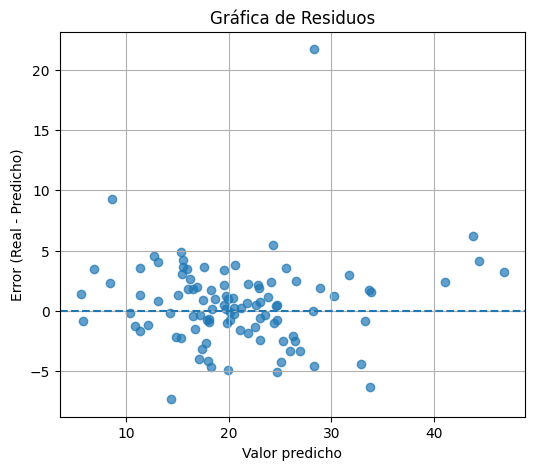

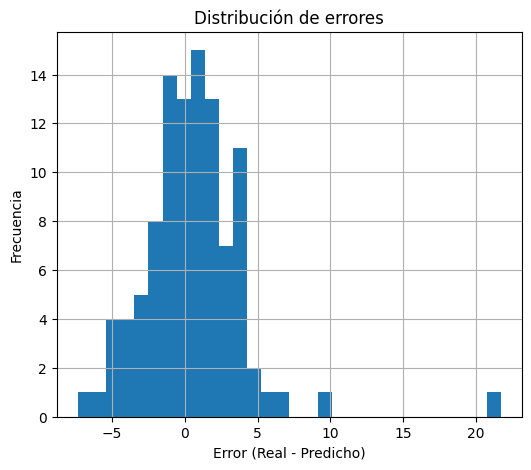

In [13]:
# 11. Real vs Predicho

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--')
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Regresión DNN - Real vs Predicho")
plt.grid(True)
plt.show()



residuos = y_test - y_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_pred, residuos, alpha=0.7)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Valor predicho")
plt.ylabel("Error (Real - Predicho)")
plt.title("Gráfica de Residuos")
plt.grid(True)
plt.show()






plt.figure(figsize=(6, 5))
plt.hist(residuos, bins=30)
plt.xlabel("Error (Real - Predicho)")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores")
plt.grid(True)
plt.show()


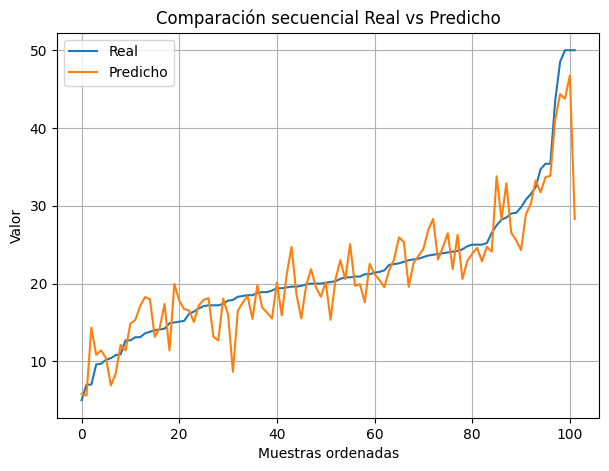

In [14]:
# Ordenar por valores reales
sorted_idx = np.argsort(y_test)

y_test_sorted = y_test.values[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(7,5))
plt.plot(y_test_sorted, label="Real")
plt.plot(y_pred_sorted, label="Predicho")
plt.xlabel("Muestras ordenadas")
plt.ylabel("Valor")
plt.title("Comparación secuencial Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()


Ejemplo 5 (RNN)

In [15]:
!pip -q install kagglehub

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf

from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [16]:
# 1. Descargar dataset desde Kaggle

path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")
print("Ruta descargada:", path)

root = Path(path)
csv_files = list(root.rglob("*.csv"))
print("CSV encontrados:", csv_files)

# Normalmente trae train y test
for f in csv_files:
    print(f.name)

# Cargar train y test
train_file = [f for f in csv_files if "Train" in f.name or "train" in f.name][0]
test_file  = [f for f in csv_files if "Test" in f.name or "test" in f.name][0]

df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)

print("\nTrain:")
print(df_train.head())

print("\nTest:")
print(df_test.head())


Using Colab cache for faster access to the 'daily-climate-time-series-data' dataset.
Ruta descargada: /kaggle/input/daily-climate-time-series-data
CSV encontrados: [PosixPath('/kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTrain.csv'), PosixPath('/kaggle/input/daily-climate-time-series-data/DailyDelhiClimateTest.csv')]
DailyDelhiClimateTrain.csv
DailyDelhiClimateTest.csv

Train:
         date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000

Test:
         date   meantemp   humidity  wind_speed  meanpressure
0  2017-01-01  15.913043  85.869565    2.743478     59.000000
1  2017-01-02  18.500000  77.222222    2.894444   1018.277778
2  2017-01-03  17.111111  81.888889   

In [18]:
# 2. Unir datasets para facilitar preprocesamiento

df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

# Convertir fecha
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("\nColumnas:", df.columns.tolist())
print("\nValores nulos:")
print(df.isnull().sum())





Columnas: ['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure']

Valores nulos:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


In [19]:
# 3. Seleccionar variables

features = ["meantemp", "humidity", "wind_speed", "meanpressure"]
target = "meantemp"

data = df[features].copy()

In [20]:
# 4. Escalado

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [21]:
# 5. Crear secuencias

window_size = 30

X = []
y = []

for i in range(window_size, len(data_scaled)):
    X.append(data_scaled[i-window_size:i])
    y.append(data_scaled[i, 0])  # 0 corresponde a meantemp

X = np.array(X)
y = np.array(y)

print("\nForma de X:", X.shape)   # (muestras, ventana, variables)
print("Forma de y:", y.shape)


Forma de X: (1546, 30, 4)
Forma de y: (1546,)


In [22]:
# 6. División train/test temporal


train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("\nTrain:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (1236, 30, 4) (1236,)
Test : (310, 30, 4) (310,)


In [23]:
# 7. Modelo RNN simple

model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# 8. Early stopping

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [25]:
# 9. Entrenamiento

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0258 - mae: 0.1091 - val_loss: 0.0109 - val_mae: 0.0859
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0054 - mae: 0.0580 - val_loss: 0.0042 - val_mae: 0.0529
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0039 - mae: 0.0487 - val_loss: 0.0037 - val_mae: 0.0474
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0037 - mae: 0.0476 - val_loss: 0.0033 - val_mae: 0.0453
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0032 - mae: 0.0439 - val_loss: 0.0031 - val_mae: 0.0436
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0031 - mae: 0.0431 - val_loss: 0.0035 - val_mae: 0.0461
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0029 - mae: 0.0416 - val_loss: 0.0029 - val_mae: 0.0423
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - mae: 0.0412 - val_loss: 0.0029 - val_mae: 0.0418
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0

In [26]:
# 10. Predicción

y_pred = model.predict(X_test, verbose=0)

In [27]:
# 11. Invertir escala solo para la variable objetivo

def invert_target_scaling(y_scaled, scaler_obj, n_features):
    aux = np.zeros((len(y_scaled), n_features))
    aux[:, 0] = y_scaled.reshape(-1)
    return scaler_obj.inverse_transform(aux)[:, 0]

y_test_inv = invert_target_scaling(y_test, scaler, len(features))
y_pred_inv = invert_target_scaling(y_pred.reshape(-1), scaler, len(features))

In [28]:
# 12. Métricas

mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred_inv)

print("\nResultados RNN")
print("-" * 40)
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")


Resultados RNN
----------------------------------------
MAE : 1.4414
MSE : 3.3023
RMSE: 1.8172
R²  : 0.9225


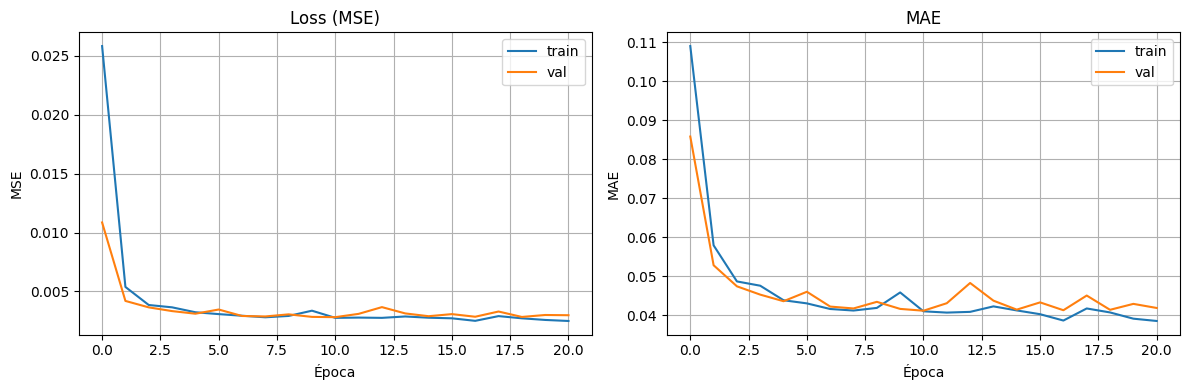

In [29]:
# 13. Gráficas de entrenamiento

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss (MSE)")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="val")
plt.title("MAE")
plt.xlabel("Época")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


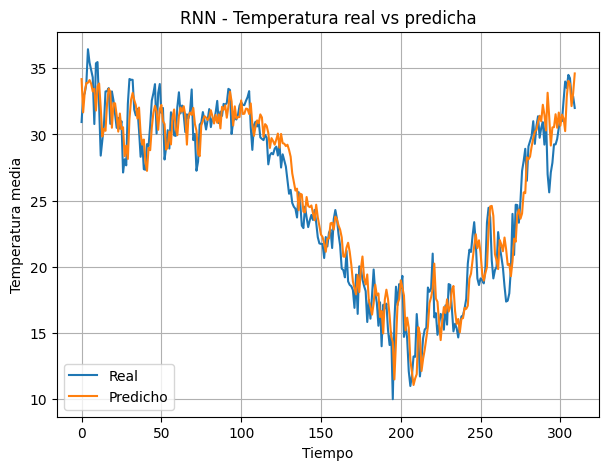

In [30]:
# 14. Real vs Predicho

plt.figure(figsize=(7,5))
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.title("RNN - Temperatura real vs predicha")
plt.xlabel("Tiempo")
plt.ylabel("Temperatura media")
plt.legend()
plt.grid(True)
plt.show()


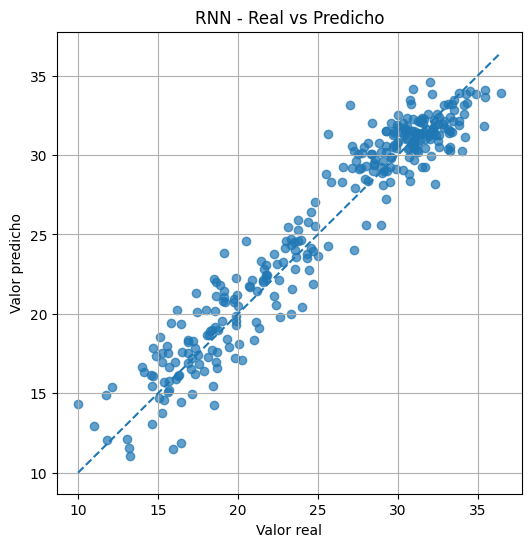

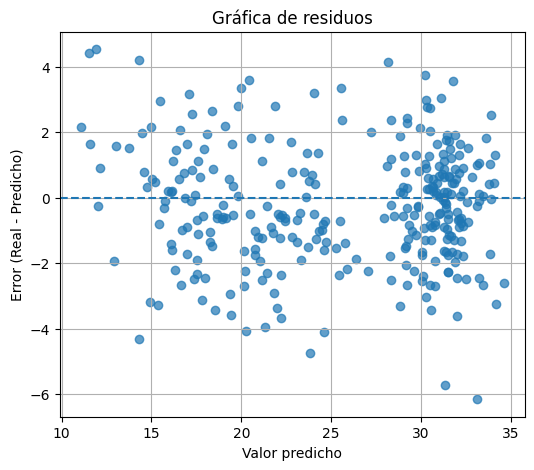

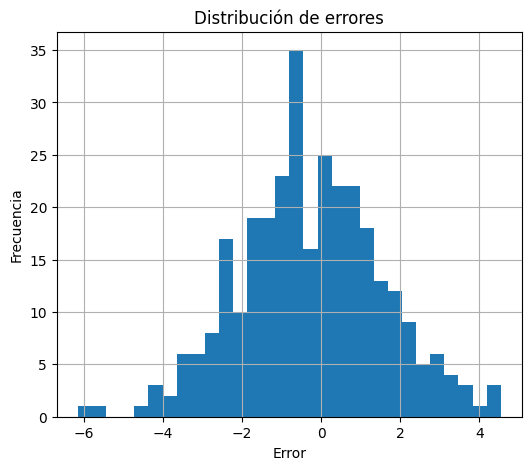

In [31]:
# 15. Scatter Real vs Predicho

plt.figure(figsize=(6,6))
plt.scatter(y_test_inv, y_pred_inv, alpha=0.7)
plt.plot([y_test_inv.min(), y_test_inv.max()],
         [y_test_inv.min(), y_test_inv.max()],
         '--')
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("RNN - Real vs Predicho")
plt.grid(True)
plt.show()

# 16. Residuos

residuos = y_test_inv - y_pred_inv

plt.figure(figsize=(6,5))
plt.scatter(y_pred_inv, residuos, alpha=0.7)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Valor predicho")
plt.ylabel("Error (Real - Predicho)")
plt.title("Gráfica de residuos")
plt.grid(True)
plt.show()



# 17. Histograma de errores
plt.figure(figsize=(6,5))
plt.hist(residuos, bins=30)
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores")
plt.grid(True)
plt.show()


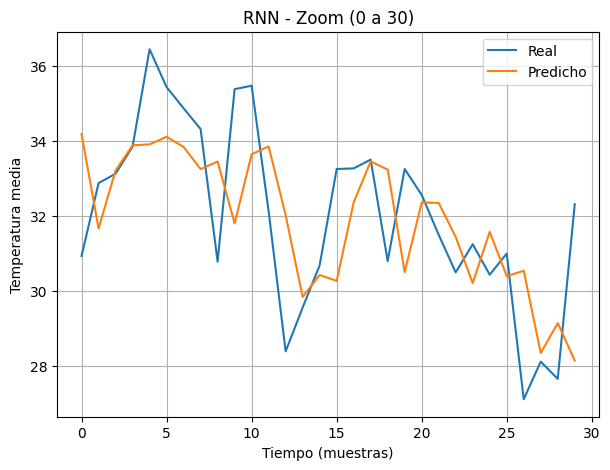

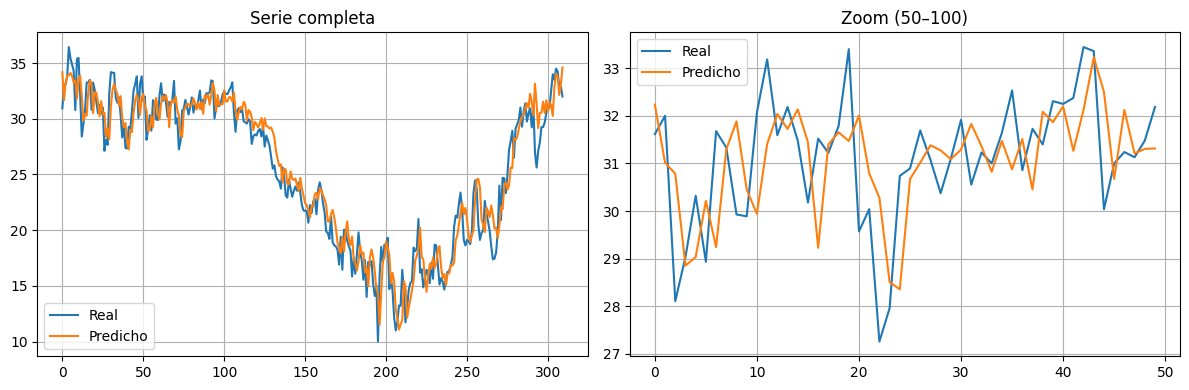

In [32]:
# 14 Continuación...

# Definir rango de zoom
inicio = 0
fin = 30

plt.figure(figsize=(7,5))
plt.plot(y_test_inv[inicio:fin], label="Real")
plt.plot(y_pred_inv[inicio:fin], label="Predicho")

plt.title(f"RNN - Zoom ({inicio} a {fin})")
plt.xlabel("Tiempo (muestras)")
plt.ylabel("Temperatura media")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(12,4))

# Global
plt.subplot(1,2,1)
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.title("Serie completa")
plt.legend()
plt.grid(True)

# Zoom
plt.subplot(1,2,2)
plt.plot(y_test_inv[50:100], label="Real")
plt.plot(y_pred_inv[50:100], label="Predicho")
plt.title("Zoom (50–100)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
